# Clustering with K-Means

*Discovering Beijing's typical pollution regimes*

## From Notebook 2 to here

In the previous notebook we used **PCA** to answer the question *"what are the axes of variability in this data?"*. We found that eleven pollutant and meteorological measurements reduce to roughly four independent directions, each with a clear physical interpretation (combustion, season, dispersion/photochemistry, rain).

In this notebook we move to a complementary question:

> *What are the typical **states** Beijing's air is in at any given hour — and how many distinct states are there?*

Where PCA gave us **directions**, clustering will give us **regimes** — recurring combinations of pollutant and weather conditions. We will call these *pollution profiles*: typical "moods" of the atmosphere, such as clean summer afternoons, winter smog nights, or windy photochemistry episodes.

By the end you will have:

1. Understood how K-Means works (objective, iterative algorithm, initialisation).
2. Chosen a sensible *k* using the elbow method and the silhouette score.
3. Fitted K-Means in the standardised 11-feature space and **read its centroids as physical pollution profiles**.
4. Confirmed those profiles are real by plotting them on several original feature pairs (PM2.5 × TEMP, O₃ × TEMP, CO × WSPM).
5. Linked clusters back to the PC1–PC2 plane from Notebook&nbsp;2 as a sanity check.

The analysis will converge on **three pollution profiles**: *winter clean (ventilated)*, *warm season*, and *winter smog (stagnant)*. A striking side-finding is that the two *winter* regimes are separated almost entirely by **wind speed**, not temperature.

---
## 1. Setup and data

We reuse the preprocessing pipeline from Notebook&nbsp;2 — same station (Aotizhongxin), same feature list, same missing-value policy (drop), and the same `StandardScaler` — so cluster distances are measured on a level playing field.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

In [2]:
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
METEO      = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
FEATURES   = POLLUTANTS + METEO

df = pd.read_csv("dataset/PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

mask     = df[FEATURES].notna().all(axis=1)
X        = df.loc[mask, FEATURES].reset_index(drop=True)
meta     = df.loc[mask, ["datetime", "month", "hour"]].reset_index(drop=True)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Rows kept:      {len(X):,}")
print(f"Feature matrix: {X_scaled.shape}")

Rows kept:      31,876
Feature matrix: (31876, 11)


---
## 2. How K-Means works

K-Means partitions the data into **k groups** so that points in the same group are as close to each other as possible, measured by squared Euclidean distance.

**Objective.** Let $\mathbf{x}_1, \dots, \mathbf{x}_n \in \mathbb{R}^d$ be the data points and $C_1, \dots, C_k$ the clusters. K-Means minimises the **within-cluster sum of squares**:

$$ J \;=\; \sum_{j=1}^{k} \sum_{\mathbf{x} \in C_j} \left\| \left(\mathbf{x} - \boldsymbol{\mu}_j\right) \right\|^{2}, \qquad \text{where } \boldsymbol{\mu}_j = \tfrac{1}{|C_j|} \sum_{\mathbf{x} \in C_j} \mathbf{x}. $$

The minimum over all partitions is NP-hard, so in practice we use **Lloyd's algorithm**, which iterates two simple steps until nothing changes:

1. **Initialise** *k* centroids $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_k$. `sklearn` uses the *k-means++* scheme, which spreads the starting centroids apart for faster and more reliable convergence.
2. **Assign** each point $\mathbf{x}_i$ to the *nearest* centroid (by squared distance).
3. **Update** each centroid to be the mean of its assigned points.
4. **Repeat** steps 2–3 until the assignments stop changing (or a max iteration count is reached).

Different random starts can converge to different local minima, so `sklearn` runs the algorithm `n_init` times and keeps the partition with the lowest *J*.

### Things to keep in mind

K-Means is fast, simple and widely used — but it makes several assumptions that matter for how we use it here:

- **You must choose *k*.** There is no "correct" value; we pick it with diagnostics (the elbow plot and silhouette score).
- **It assumes spherical, similarly-sized clusters.** On elongated or density-varying groups it can split a natural cluster in two, or merge two real clusters into one.
- **It is sensitive to outliers.** Extreme points pull their cluster's mean.
- **It is sensitive to feature scale** — same reason as PCA. A feature with large numeric range dominates the distance. We address this by standardising with `StandardScaler`.
- **It does not tell you whether the clusters are meaningful.** It just finds the best partition for the *k* you asked for. Interpretation is on us.

---
## 3. The `sklearn.cluster.KMeans` API

Typical use:

```python
km = KMeans(n_clusters=k, n_init=10, random_state=0)
km.fit(X_scaled)              # learn the centroids
labels = km.predict(X_scaled) # cluster assignments (same as km.labels_ after fit)
```

Key attributes after `fit`:

| Attribute | Shape | What it is |
|---|---|---|
| `km.labels_` | `(n_samples,)` | cluster index (0..k-1) for each row. |
| `km.cluster_centers_` | `(k, n_features)` | coordinates of the **k** centroids in the **same space** you fitted on (here: standardised feature space). |
| `km.inertia_` | scalar | final value of the objective **J** — sum of squared distances to assigned centroids. |
| `km.n_iter_` | scalar | number of Lloyd's iterations run. |

> **`n_init` matters.** With a single random start K-Means can land in a bad local minimum. `n_init=10` (the default in recent `sklearn` versions) is usually enough, and we'll stick with it.

---
## 4. Choosing *k*: elbow plot and silhouette score

Because K-Means has no built-in stopping criterion for *how many* clusters to use, we compute two diagnostics over a range of *k*:

- **Inertia (WCSS)** — the objective *J* itself. It *always* decreases as *k* grows (more centroids ⇒ shorter distances), but the *rate* of improvement slows. The "elbow" is where extra clusters stop buying much reduction.
- **Silhouette score** — a standardised measure in [-1, 1] that compares, for each point, its average distance to its own cluster versus its average distance to the nearest *other* cluster. Higher is better. Peaks in this curve suggest natural values of *k*.

Neither is decisive on its own — they are *guides*, not verdicts.

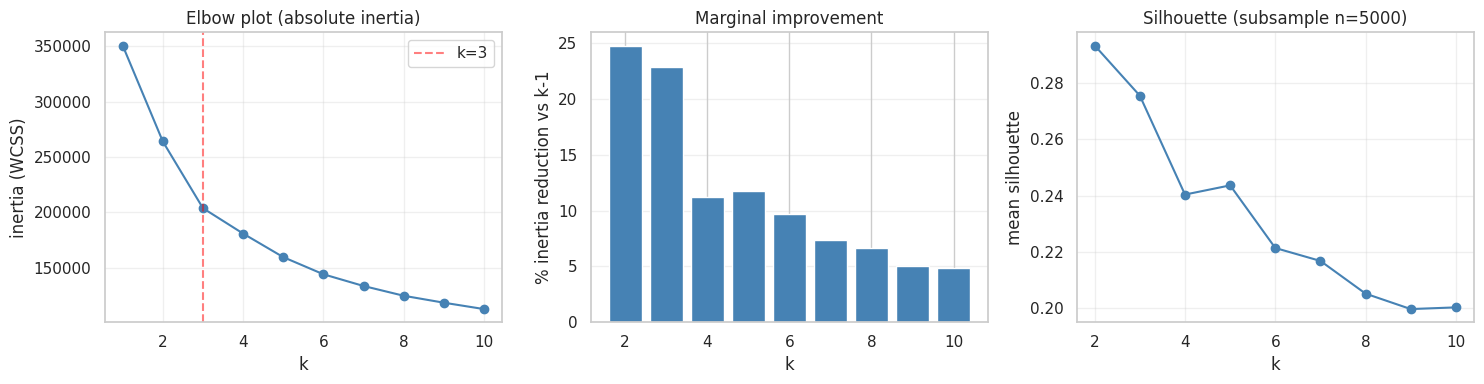

,k,inertia,silhouette,pct_reduction
0,1,350636.00,NaN,NaN
1,2,263931.23,0.29,24.73
2,3,203652.68,0.28,22.84
3,4,180733.41,0.24,11.25
4,5,159453.57,0.24,11.77
5,6,143964.24,0.22,9.71
6,7,133379.22,0.22,7.35
7,8,124553.54,0.20,6.62
8,9,118283.54,0.20,5.03
9,10,112518.69,0.20,4.87


In [3]:
K_RANGE = range(1, 11)

# Silhouette is O(n^2): subsample for a responsive computation
rng = np.random.default_rng(0)
sub  = rng.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)

diag = []
for k in K_RANGE:
    km  = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_scaled)
    sil = silhouette_score(X_scaled[sub], km.labels_[sub]) if k >= 2 else np.nan
    diag.append({"k": k, "inertia": km.inertia_, "silhouette": sil})
diag = pd.DataFrame(diag)
diag["pct_reduction"] = (
    diag["inertia"].shift(1).sub(diag["inertia"]).div(diag["inertia"].shift(1)) * 100
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(diag["k"], diag["inertia"], "o-", color="steelblue")
axes[0].axvline(3, color="red", linestyle="--", alpha=0.5, label="k=3")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia (WCSS)")
axes[0].set_title("Elbow plot (absolute inertia)")
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].bar(diag["k"][1:], diag["pct_reduction"][1:],
            color="steelblue", edgecolor="white")
axes[1].set_xlabel("k"); axes[1].set_ylabel("% inertia reduction vs k-1")
axes[1].set_title("Marginal improvement")
axes[1].grid(axis="y", alpha=0.3)

axes[2].plot(diag["k"][1:], diag["silhouette"][1:], "o-", color="steelblue")
axes[2].set_xlabel("k"); axes[2].set_ylabel("mean silhouette")
axes[2].set_title(f"Silhouette (subsample n={len(sub)})")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

diag.round(3)

What the diagnostics say:

- The **biggest jump** in inertia happens from *k* = 2 → 3 (≈ 23% reduction). The **marginal improvement** panel makes this visible as a clear step, after which successive additions buy only about 10% each.
- **Silhouette peaks at low *k*** and declines as more clusters are added. *k* = 2 and *k* = 3 are the only regions of the curve that stay above 0.27; from *k* = 4 onward the mean silhouette keeps sliding downward.
- The overall shape is typical of data that is a **continuum with a few dominant modes** rather than a set of well-separated blobs. No sharp elbow should be expected.

Both diagnostics therefore vote for **k = 3**: the biggest structural gain comes at that point, and the silhouette is still reasonably high. Going further (*k* ≥ 4) tends to split an existing regime into two sub-regions rather than reveal a new one.

We will use **k = 3** as the main analysis. You will have a chance to probe *k* = 4 and *k* = 5 in a mini-exercise at the end of the notebook, and to see for yourself whether the extra clusters carry independent information.

---
## 5. Fitting K-Means with *k* = 3

We fit the model, then **relabel clusters by increasing mean PM2.5** so that numbering is reproducible and ordered by pollution severity (cluster&nbsp;0 = cleanest, cluster&nbsp;K&minus;1 = dirtiest). Cluster ids from K-Means are arbitrary; consistent sorting is a presentation choice.

In [4]:
K = 3
km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_scaled)

# Relabel so cluster index reflects PM2.5 severity (0 = lowest, K-1 = highest)
raw_labels = km.labels_
order      = X.groupby(raw_labels)["PM2.5"].mean().sort_values().index
remap      = {old: new for new, old in enumerate(order)}
labels     = np.array([remap[c] for c in raw_labels])

print(f"Inertia:       {km.inertia_:,.0f}")
print(f"Iterations:    {km.n_iter_}")
print(f"Cluster sizes: {pd.Series(labels).value_counts().sort_index().to_dict()}")

Inertia:       203,653
Iterations:    10
Cluster sizes: {0: 10514, 1: 14959, 2: 6403}


---
## 6. Centroids — reading the pollution profiles

Each cluster's centroid is a point in the 11-dimensional standardised feature space. The *most useful* way to read it is **in the original physical units** — we take the mean of each raw feature within the cluster. The heatmap below shows z-scored deviations from the overall mean (colour) with the raw average numbers written on each cell.

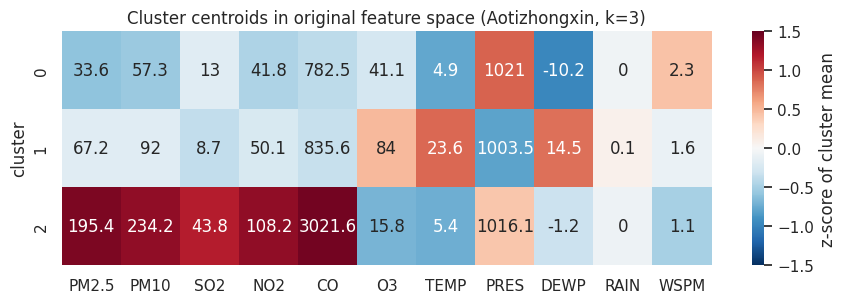

In [5]:
X_with = X.copy(); X_with["cluster"] = labels
means_raw = X_with.groupby("cluster")[FEATURES].mean()
means_z   = (means_raw - X.mean()) / X.std()

fig, ax = plt.subplots(figsize=(9, 3.2))
sns.heatmap(
    means_z, annot=means_raw.round(1), fmt="g",
    cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5,
    cbar_kws={"label": "z-score of cluster mean"}, ax=ax,
)
ax.set_title("Cluster centroids in original feature space (Aotizhongxin, k=3)")
ax.set_ylabel("cluster"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

Read each row as one "typical hour" for that cluster. Before scrolling down, try to give each row a descriptive name based on its values.

<details>
<summary><b>Our interpretation (click to expand)</b></summary>

Using the centroid values (approximate, your numbers will match):

| Cluster | PM2.5 | CO | O₃ | TEMP | WSPM | Suggested name |
|---|---|---|---|---|---|---|
| **0** | ≈ 34 | ≈ 780 | 41 | **4.9 °C** | **2.3 m/s** | **Winter clean — ventilated** |
| **1** | 67 | 836 | 84 | **23.6 °C** | 1.6 | **Warm season** (summer + shoulders) |
| **2** | **195** | **3020** | 16 | 5.4 | **1.1** | **Winter smog — stagnant** |

- **Cluster 0 — "Winter clean".** Cold, *windy*, modest pollution. Despite the low temperatures, strong winds ventilate the boundary layer and carry combustion products away. These are the "good" winter days.
- **Cluster 1 — "Warm season".** Warm, humid, low PM, elevated ozone — dominated by summer photochemistry but also absorbing milder spring and autumn hours. (If we later push to *k* = 4, this cluster will naturally split into a dedicated summer photochemistry regime and a shoulder-season transitional one.)
- **Cluster 2 — "Winter smog".** Cold like cluster&nbsp;0, but **wind speeds collapse to ≈1 m/s** and CO climbs to ≈3000 µg/m³. This is the classic Beijing stagnation episode: emissions (traffic + heating) accumulate under a shallow, windless layer.

The single most informative distinction among the three profiles is not *season* per se but **what happens to the wind** in winter. Clusters&nbsp;0 and&nbsp;2 are both cold, yet they are opposite extremes of air quality — separated almost entirely by WSPM. That is a genuine, non-trivial finding of the clustering.
</details>

---
## 7. Seeing the clusters on original feature pairs

Clusters were found in the 11-dimensional standardised space. To *trust* them we want to see that they look coherent on any sensible 2-D slice of the data. Below we plot the three clusters on three physically meaningful pairs:

- **PM2.5 × TEMP** — separates the two winter regimes from the warm season.
- **O₃ × TEMP** — puts the photochemistry-heavy warm-season hours in the upper right.
- **CO × WSPM** — shows the stagnation mechanism explicitly.

If the clusters are real, they should look tight and non-overlapping on at least some of these views — even though K-Means never "saw" any of these 2-D projections directly.

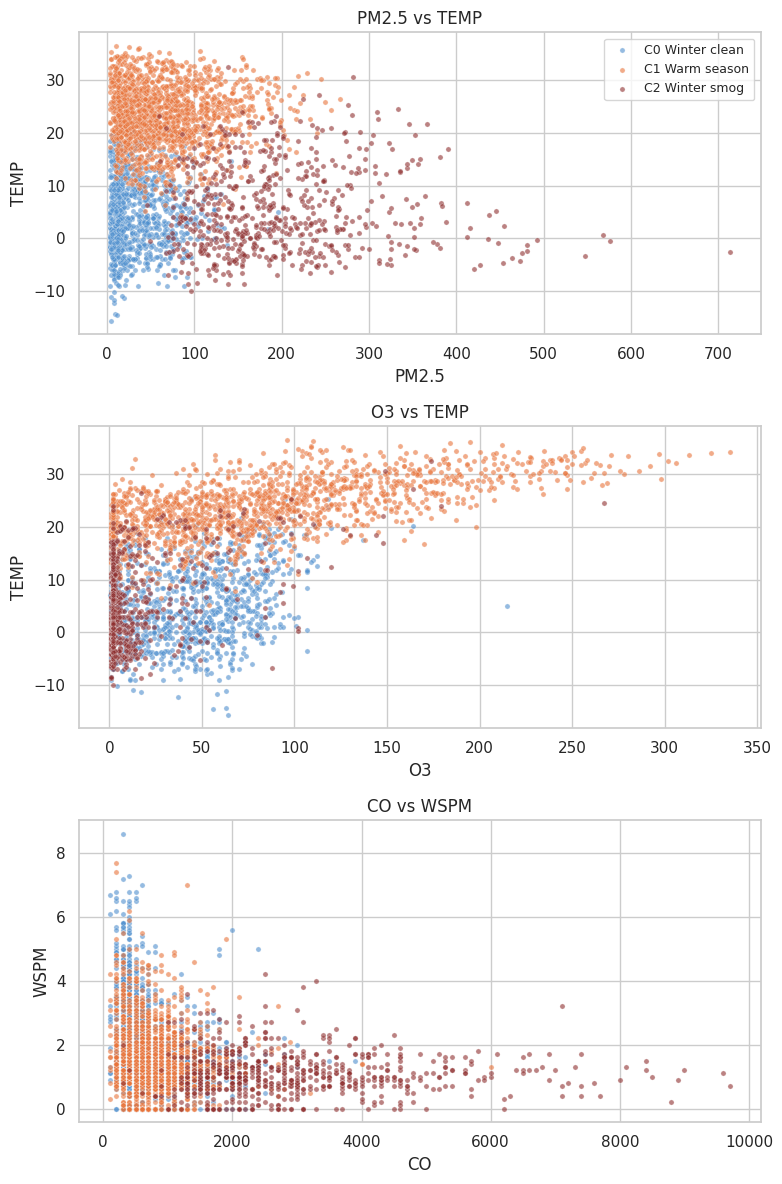

In [6]:
palette = {0: "#4E8FCE", 1: "#E8743B", 2: "#8E2F2F"}
names   = {0: "C0 Winter clean",
           1: "C1 Warm season",
           2: "C2 Winter smog"}

idx = np.arange(0, len(X), 10)       # thin to ~3000 points for clarity
pairs = [("PM2.5", "TEMP"), ("O3", "TEMP"), ("CO", "WSPM")]

fig, axes = plt.subplots(len(pairs), 1, figsize=(8, 4 * len(pairs)))
for ax, (fx, fy) in zip(axes, pairs):
    for c in range(K):
        m = labels[idx] == c
        ax.scatter(
            X[fx].values[idx][m], X[fy].values[idx][m],
            s=14, alpha=0.6, color=palette[c], label=names[c],
            edgecolor="white", linewidth=0.3,
        )
    ax.set_xlabel(fx); ax.set_ylabel(fy)
    ax.set_title(f"{fx} vs {fy}")

axes[0].legend(loc="best", fontsize=9, frameon=True)
plt.tight_layout(); plt.show()

Each view tells a consistent story:

- **PM2.5 × TEMP.** Winter smog (dark red) occupies the high-PM cold zone; winter clean (blue) is low-PM, cold, and vertically aligned with winter smog — confirming that temperature alone does not separate the two. The warm-season cluster (orange) sits at the top.
- **O₃ × TEMP.** The warm-season cluster is stretched along the high-O₃ / warm ridge — high ozone only occurs with warm temperatures, as expected.
- **CO × WSPM.** This is where the **stagnation mechanism** pops out: winter-smog points stretch along the high-CO / low-wind ridge, while winter-clean points sit at moderate wind and moderate CO. The wind axis really is what separates the two cold regimes.

The fact that the clusters look sensible on *three different* feature pairs — none of which was used directly in the clustering distance — is a strong signal that we have found real atmospheric structure, not a numerical coincidence.

---
## 8. When does each profile occur?

A proposed name like *"winter smog"* carries a time-of-year prediction: such hours should be rare in July. We test this by computing, for each calendar month, the fraction of hours that fall into each cluster.

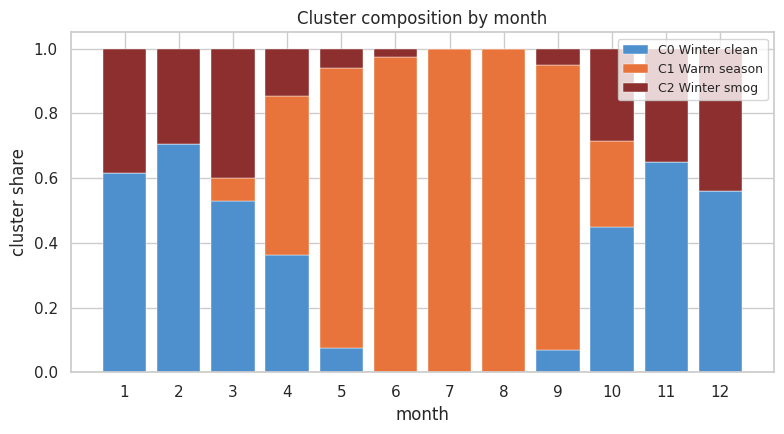

In [7]:
dfc = meta.copy(); dfc["cluster"] = labels

by_month = (dfc.groupby(["month", "cluster"]).size()
              .unstack(fill_value=0)
              .apply(lambda r: r / r.sum(), axis=1))

fig, ax = plt.subplots(figsize=(8, 4.5))
bottoms = np.zeros(len(by_month))
for c in range(K):
    ax.bar(by_month.index, by_month[c], bottom=bottoms,
           color=palette[c], label=names[c], edgecolor="white", linewidth=0.3)
    bottoms += by_month[c].values
ax.set_xlabel("month"); ax.set_ylabel("cluster share")
ax.set_title("Cluster composition by month")
ax.set_xticks(range(1, 13))
ax.legend(loc="upper right", fontsize=9, frameon=True)
plt.tight_layout(); plt.show()

The monthly composition matches the cluster names. *Warm season* (orange) dominates **May through September** and is essentially absent in deep winter. *Winter smog* and *winter clean* (dark red and blue) span **October through April**, sharing the cold months and differing only in ventilation.

None of this was used as an input to K-Means. Cluster names survive independent validation against the calendar — a solid sign that the profiles are physical.

---
## 9. A bridge back to Notebook&nbsp;2 — clusters in PC space

In Notebook&nbsp;2 we saw that PC1 (combustion) and PC2 (season) give a compact 2-D map of the data, with a clear seasonal structure. If our clusters are genuine pollution profiles they should occupy distinct regions of that same PC1–PC2 plane — even though K-Means was fitted in the full 11-dimensional standardised space, with no knowledge of PCA.

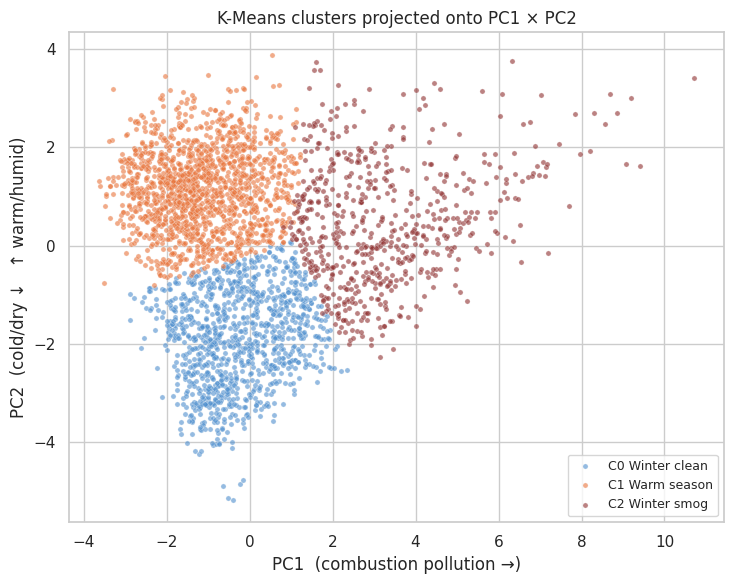

In [8]:
pca = PCA(n_components=2).fit(X_scaled)
scores = pca.transform(X_scaled)

idx = np.arange(0, len(scores), 10)

fig, ax = plt.subplots(figsize=(7.5, 6))
for c in range(K):
    m = labels[idx] == c
    ax.scatter(
        scores[idx][m, 0], scores[idx][m, 1],
        s=14, alpha=0.6, color=palette[c], label=names[c],
        edgecolor="white", linewidth=0.3,
    )
ax.set_xlabel("PC1  (combustion pollution \u2192)")
ax.set_ylabel("PC2  (cold/dry \u2193   \u2191 warm/humid)")
ax.set_title("K-Means clusters projected onto PC1 \u00d7 PC2")
ax.legend(loc="lower right", fontsize=9, frameon=True)
plt.tight_layout(); plt.show()

The three clusters separate cleanly on PC1–PC2 even though neither axis was used during fitting. The **warm-season** cluster (orange) lives in the **upper region** (high PC2 = warm/humid). **Winter clean** (blue) sits in the **lower region** (low PC2 = cold/dry), spanning a moderate range of PC1 around zero. **Winter smog** (dark red) stretches as a **tail to the right** along high PC1 — the combustion-pollution axis — at moderate PC2 values.

The match between two *independent* constructions — PCA directions in NB2 and K-Means regions in NB3 — is strong evidence that the structure we are describing is really present in the data.

---
## 10. Mini-exercise 1 — does *k* = 4 reveal a genuinely new profile?

We chose *k* = 3 because the diagnostics and interpretability both pointed there. But the diagnostics are guides, not verdicts, and Beijing's air has more than three textures of pollution. A reasonable follow-up question: **if we allow one more cluster, does it reveal a genuinely new regime, or does K-Means just split an existing one?**

**Task.** Run K-Means with *k* = 4, inspect the centroid heatmap, and compare to the *k* = 3 result from earlier. Which of the three original clusters gets split? Does the resulting pair of sub-clusters describe two different phenomena, or is it the same phenomenon split in half? Try *k* = 5 too — at what point does K-Means start pulling out tiny, unmeaningful clusters?

k=4 cluster sizes: {0: 9223, 1: 7502, 2: 9826, 3: 5325}



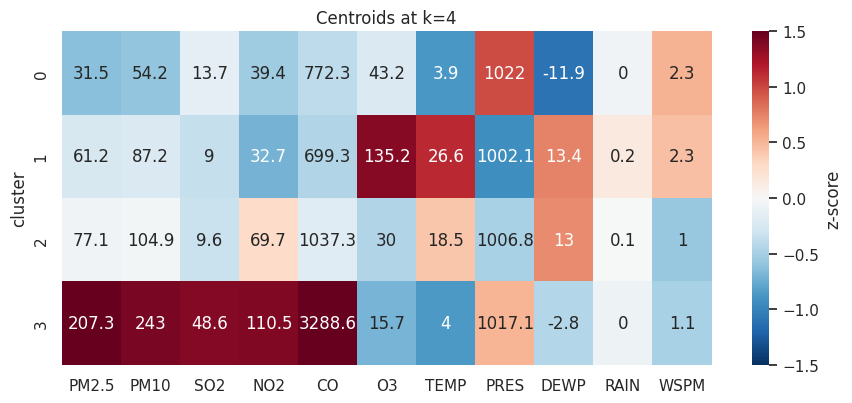

In [9]:
K_TRY = 4   # <-- try 4 first, then 5

km_try  = KMeans(n_clusters=K_TRY, n_init=10, random_state=0).fit(X_scaled)
ord_try = X.groupby(km_try.labels_)["PM2.5"].mean().sort_values().index
rem_try = {old: new for new, old in enumerate(ord_try)}
lab_try = np.array([rem_try[c] for c in km_try.labels_])

sizes = pd.Series(lab_try).value_counts().sort_index()
print(f"k={K_TRY} cluster sizes: {sizes.to_dict()}\n")

Xc = X.copy(); Xc["cluster"] = lab_try
mraw = Xc.groupby("cluster")[FEATURES].mean()
mz   = (mraw - X.mean()) / X.std()

fig, ax = plt.subplots(figsize=(9, 0.55 * K_TRY + 2))
sns.heatmap(mz, annot=mraw.round(1), fmt="g",
            cmap="RdBu_r", center=0, vmin=-1.5, vmax=1.5,
            cbar_kws={"label": "z-score"}, ax=ax)
ax.set_title(f"Centroids at k={K_TRY}")
plt.tight_layout(); plt.show()

With *k* = 4, the **warm-season** cluster from *k* = 3 splits in two:

- one sub-cluster is dominated by **summer photochemistry** — very high O₃ (~135 µg/m³), warmest temperatures, clean PM;
- the other is a **mild / transitional** regime — moderate temperature, moderate PM, lower O₃, lower wind. It absorbs spring and autumn hours that did not quite belong to the summer photochemistry or the winter regimes.

This is a **genuine refinement**: summer photochemistry and shoulder-season mild days are physically distinct phenomena. But at *k* = 3 they were bundled together because the clustering objective did not need the extra axis to explain the bulk of the variance.

With *k* = 5, K-Means typically starts splitting physically identical regimes in two, or pulling out a small cluster of unusual points (e.g. rain-affected hours) — you'll see cluster sizes become unbalanced and the fifth cluster becomes hard to interpret cleanly.

**Take-away.** More clusters always fit the data better, but not every additional cluster carries new physical meaning. The boundary between "useful refinement" and "over-fitting the partition" is a judgement call, guided by domain interpretation as much as by metrics.

---
## 11. Mini-exercise 2 — does it matter whether we cluster in PC space or raw space?

Throughout this notebook we clustered in the **11-dimensional standardised feature space**. An alternative would be to cluster on the **4 principal-component scores** from Notebook&nbsp;2. Would we get the same assignments?

The **Adjusted Rand Index (ARI)** measures how similar two clusterings are, correcting for chance. ARI = 1 means identical assignments; ARI = 0 means no more agreement than random.

**Task.** Fit K-Means on `pca4_scores = PCA(n_components=4).fit_transform(X_scaled)` and compute the ARI against `labels`. What do you predict the ARI will be — close to 0, close to 1, or somewhere in between?

In [10]:
pca4_scores = PCA(n_components=4).fit_transform(X_scaled)

km_pc = KMeans(n_clusters=K, n_init=10, random_state=0).fit(pca4_scores)

# Relabel consistently (by PM2.5, in the *original* feature space)
ord_pc = X.groupby(km_pc.labels_)["PM2.5"].mean().sort_values().index
rem_pc = {old: new for new, old in enumerate(ord_pc)}
lab_pc = np.array([rem_pc[c] for c in km_pc.labels_])

ari = adjusted_rand_score(labels, lab_pc)
print(f"ARI (raw-space vs 4-PC clustering): {ari:.3f}")

# Where do they disagree?
confusion = pd.crosstab(labels, lab_pc, rownames=["raw"], colnames=["PC"])
confusion

ARI (raw-space vs 4-PC clustering): 0.988


PC,0,1,2
raw,,,
0,10489,23,2
1,16,14943,0
2,51,43,6309


You should see **ARI &approx; 0.99** — the two clusterings agree on nearly all points. The confusion table shows that disagreements are a handful of boundary cases at the edges of the warm-season cluster; the two winter regimes are essentially identical in both spaces.

Take-away: **the three pollution profiles we identified are robust to this modelling choice**. PCA removes low-variance noise before clustering, which can make distances cleaner, but the physical story is the same. Knowing this, we can feel safe using the raw-space clustering throughout the notebook — its centroids are directly readable as pollutant concentrations and weather values, which is easier to interpret.

---
## Recap

- **K-Means partitions data into *k* groups** by iteratively minimising within-cluster sum of squared distances.
- **Choosing *k* is a modelling decision** guided by elbow and silhouette diagnostics, plus domain interpretability. For Aotizhongxin, *k* = 3 produced three physically coherent profiles; going to *k* = 4 refines the warm season into summer photochemistry and mild transitional, which is a reasonable extension but not strictly required.
- **Pollution profiles found.** (i) Winter clean / ventilated, (ii) warm season, (iii) winter smog / stagnant. The two *winter* profiles are separated almost entirely by **wind speed**, not temperature — a non-trivial insight the clustering surfaced on its own.
- **Independent validation.** The profiles line up with the calendar (monthly composition) without that being an input, and they occupy clean regions of the PC1–PC2 plane from Notebook&nbsp;2. K-Means and PCA converge on the same physical story.
- **Always standardise** distance-based methods. Same rule as PCA.

### Check your understanding

1. K-Means is initialised randomly. Why does `sklearn` run it multiple times (`n_init`) and keep the result with the lowest inertia?
2. You rerun the elbow plot on a different station and find no clear elbow. What does that suggest about the data — and what would you do next?
3. Our two winter clusters differ mainly in WSPM, not TEMP. What would break if we had *dropped* WSPM from the feature set before clustering?

*(Answers: 1 — because different initialisations converge to different local minima; keeping the best guards against a bad starting point. 2 — the data may not have a clear cluster structure, or the clusters may be non-spherical (which K-Means struggles with). Try looking at the silhouette score, or consider density-based methods like DBSCAN. 3 — the winter-smog vs winter-clean distinction would collapse; those two regimes would merge into a single "cold, polluted" cluster, because temperature alone does not separate them.)*

---

### Next up

**Notebook&nbsp;4 — DBSCAN for anomaly detection, and source apportionment.** K-Means partitions *every* hour into some cluster. DBSCAN instead finds *dense regions* and labels everything else as noise — perfect for spotting faulty sensors or unusual pollution events. We will also revisit the PCA loadings in the light of known emission sources.